Last edited: 1/28/2026, 3:38 PM CST
# Bias vs. Variance Explained Analysis for Nonstationary GEV Fits to CMIP6 Models
## All mems + primary mems

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import linregress

from evt_heat_waves.config import ERA5_PATH, MIP_FIT_PATH_DICT, MLE_FIT_ATTRS
from evt_heat_waves.utils import extract_model_name
from evt_heat_waves.mip_fit.cmip_dataclass import CMIP6EnsembleConfig
from evt_heat_waves.plotting.plotting_presets import get_presets
from evt_heat_waves.plotting.bias_vs_corr import (mutual_mask_perc, plot_scatter_regression,
                                                  plot_bias_vs_corr, compute_primary_member_bias_vs_corr)

presets, _ = get_presets(markers=False)
plt.rcParams.update(presets)

# set random attributes
np.random.seed(4)

SAVE_FIGS = True

## Step 0: Set Data Attributes for Analysis

In [2]:
trend_vars = ['loc_t', 'scale_t', 'shape_t']

In [3]:
# shared attributes
primary_fit = 'stat_gumbel'  # from mle_attrs.yaml
secondary_fit = 'nonstat_gumbel_only_loc_trend'  # from mle_attrs.yaml
anom_type = 'annmean'  # raw, trend, or annmean
ex_type = 'max'  # max or min

# set anomaly type
data_type = 'raw' if anom_type == 'raw' else f"anom_{anom_type}"

In [4]:
# attributes of ERA5 data
TMIN = 1979  # 1979 or 1950
era5_variable = f't2m_annual_{ex_type}'
GRID = '1deg'

In [5]:
# attributes of CMIP data
cmip_variable = f'tas_annual_{ex_type}'
mip = 'amip'  # amip or cmip

In [6]:
primary_fit_output = compute_primary_member_bias_vs_corr(primary_fit,
                                                         anom_type,
                                                         ex_type,
                                                         data_type,
                                                         TMIN,
                                                         GRID,
                                                         mip)

secondary_fit_output = compute_primary_member_bias_vs_corr(secondary_fit,
                                                           anom_type,
                                                           ex_type,
                                                           data_type,
                                                           TMIN,
                                                           GRID,
                                                           mip)

primary_vars = ['loc', 'scale']
secondary_vars = ['loc_t']

final_output = {}
for var_key in ['med_abs_dev_prim', 'med_abs_dev_most', 'mean_abs_dev_prim', 'mean_abs_dev_most', 'r2s_prim', 'r2s_most']:
    merged = {}
    merged.update({k: primary_fit_output[var_key][k] for k in primary_vars})
    merged.update({k: secondary_fit_output[var_key][k] for k in secondary_vars})
    final_output[var_key] = merged


IndexError: list index out of range

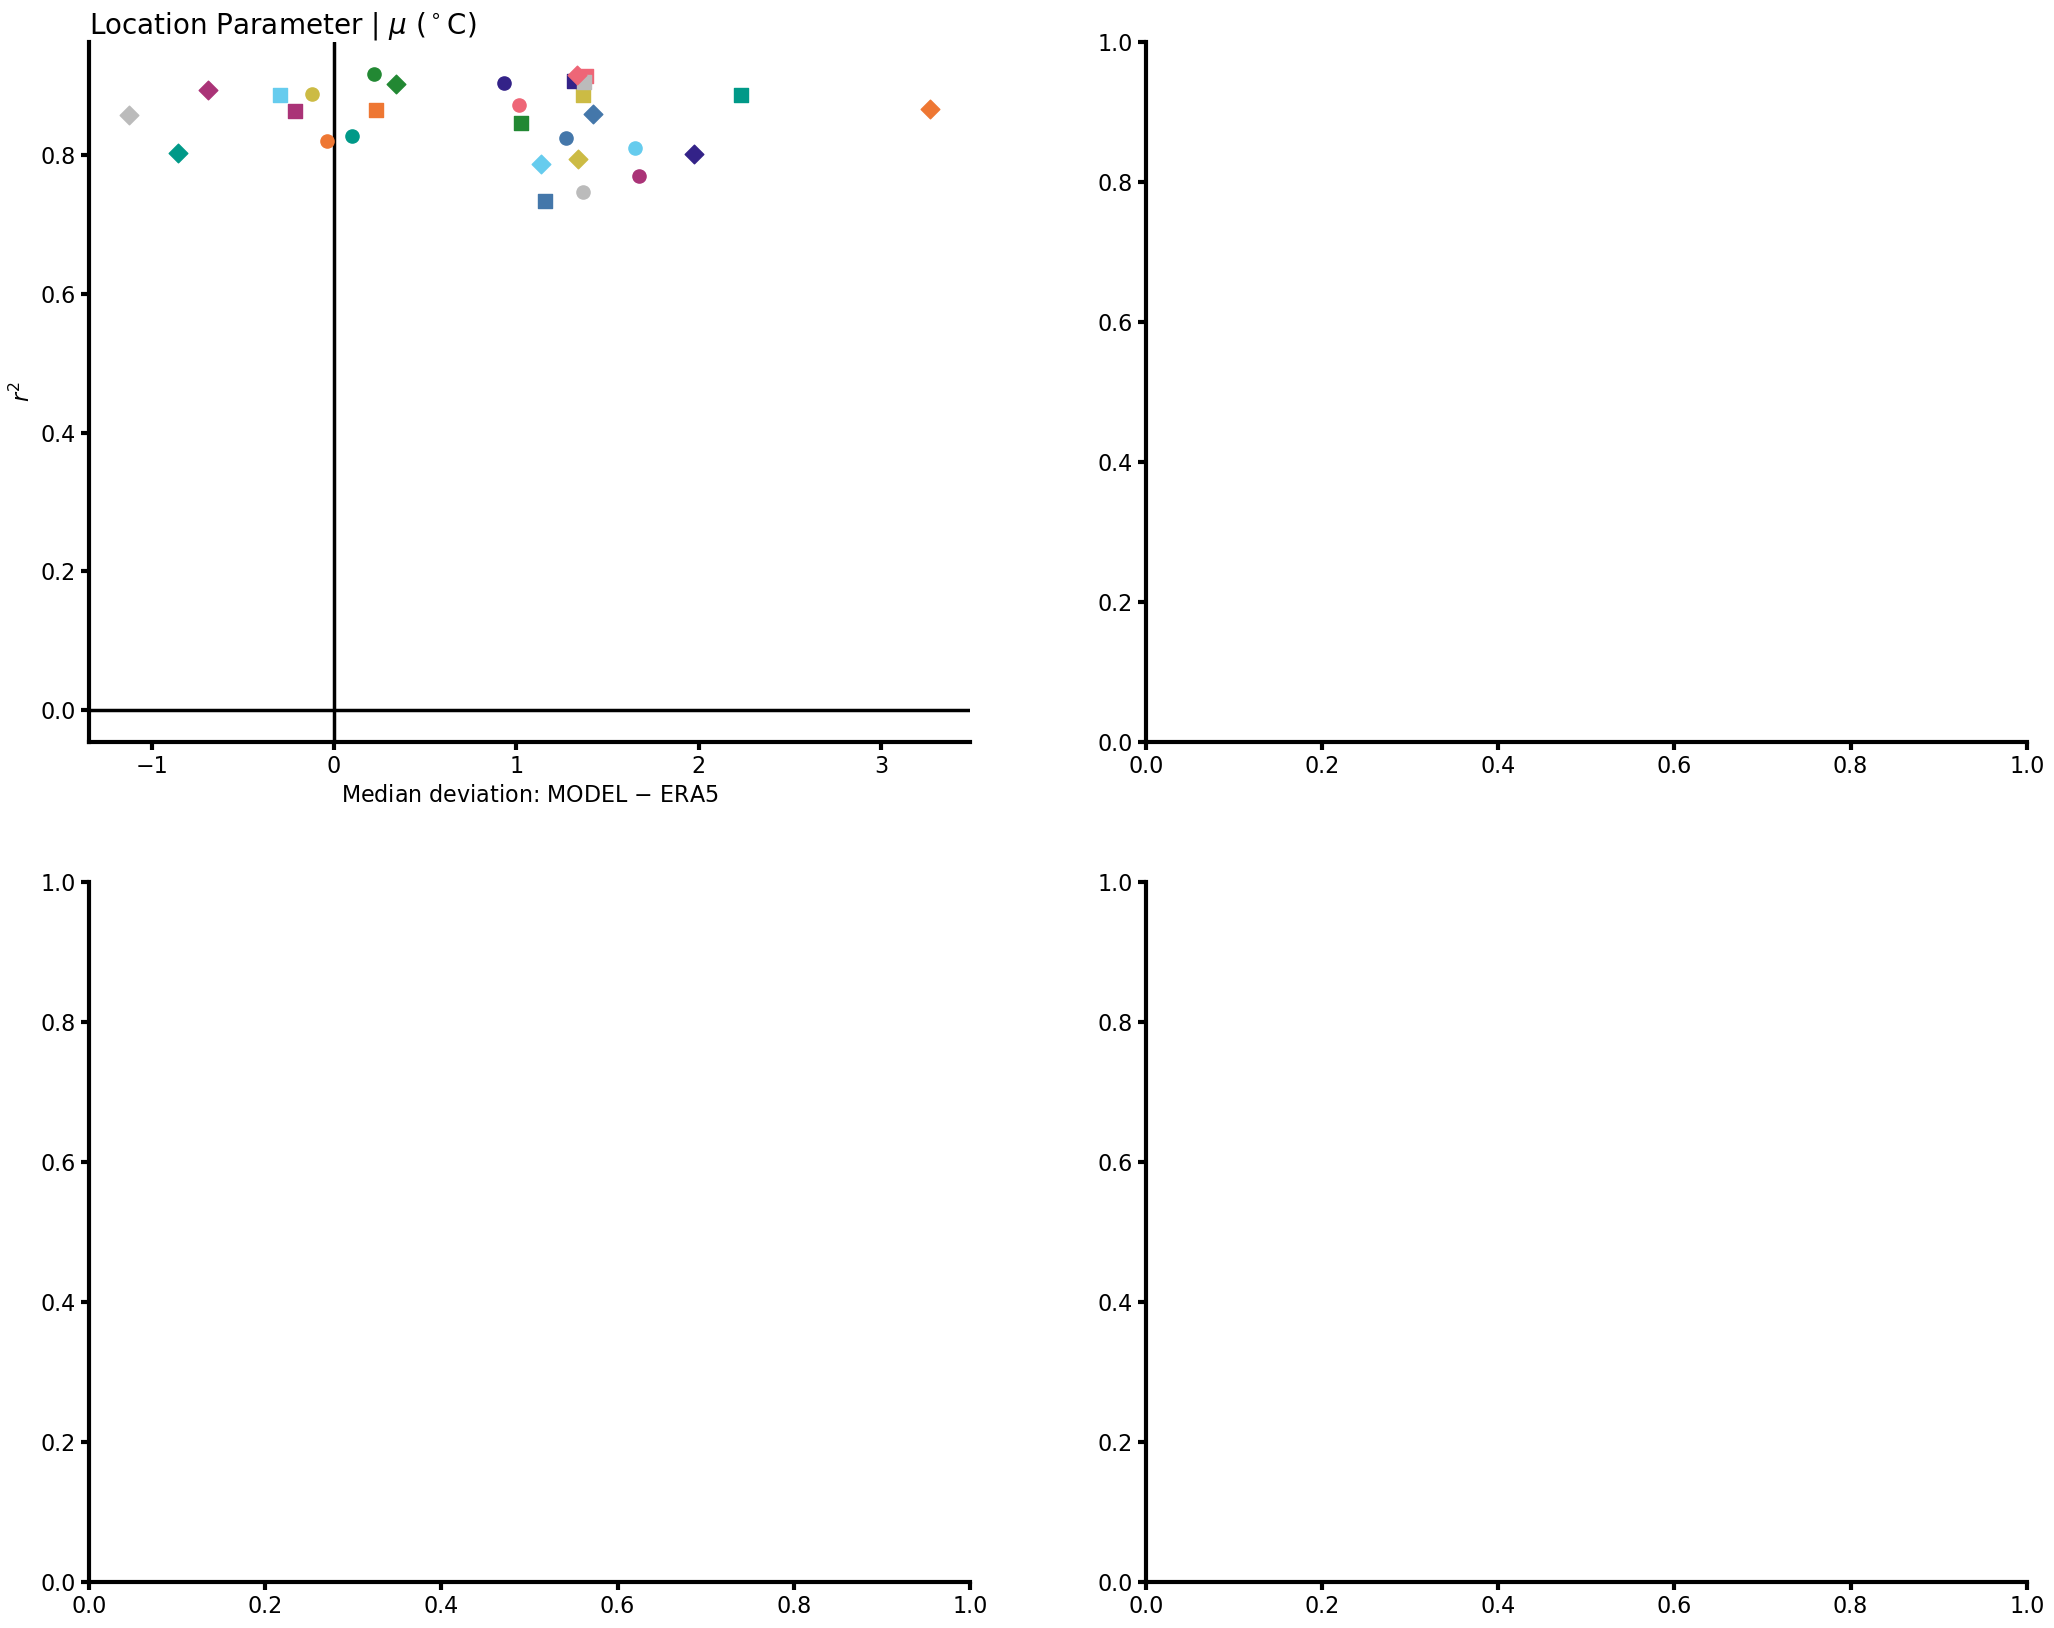

In [8]:
plot_bias_vs_corr(
    abs_dev_prim=final_output['med_abs_dev_prim'], r2s_prim=final_output['r2s_prim'],
    abs_dev_most=final_output['med_abs_dev_most'], r2s_most=final_output['r2s_most'],
    param_order=['loc', 'scale', 'loc_t'], N_params=3,
    models=list(primary_fit_output['cmip_config'].iter_active_models(cmip_variable)),
    model_with_most=primary_fit_output['model_with_most'], med_or_mean='med',
    fname=f'all_cmip_era5_r2_medbias_{cmip_variable}_{anom_type}_{primary_fit}_{secondary_fit}_hybrid',
    save_figs=False
)

In [ ]:
CMIPConfig = CMIP6EnsembleConfig.from_yaml(
    MIP_FIT_PATH_DICT[mip]['config']['meta'],
    MIP_FIT_PATH_DICT[mip]['config']['qc']
)

# make file/model matcher for 
data_path = MIP_FIT_PATH_DICT[mip]['data'] / cmip_variable / 'gev'

# Make all landonly file names
fnames_prim = [f for f in data_path.glob(f"*_{primary_fit}_*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results
fnames_secondary = [f for f in data_path.glob(f"*_{secondary_fit}_*{anom_type}*.nc") if "allmems" not in f.name]  # screen out allmems results

modelname_filepath_matcher = {
    extract_model_name(f): f for f in fnames_prim
}

## Step 1: Import ERA5 Data and Initialize Quantities of Interest for CMIP Comparison

In [7]:
# import relevant ERA5 file
ds_era5 = xr.open_dataset(ERA5_PATH / 'gev' / f'era5_{era5_variable}_{GRID}_landonly_gev_{fit}_TMIN{TMIN}_{anom_type}.nc', engine='netcdf4')
PER_DECADE_CONVERSTION_FACTOR = 10 / len(ds_era5.year.values)

era5_data = {p: ds_era5[f'{p}_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
             if p in trend_vars
             else ds_era5[f'{p}_{data_type}'].values.flatten()
             for p in MLE_FIT_ATTRS[fit]['param_names']
}

Setup for primary model member analysis.

In [8]:
# get number of models for this variable
N_active_models = len(
    list(m for m in CMIPConfig.iter_active_models(cmip_variable))
)

med_abs_dev_prim = {p: np.zeros(N_active_models) for p in MLE_FIT_ATTRS[fit]['param_names']}
mean_abs_dev_prim = {p: np.zeros(N_active_models) for p in MLE_FIT_ATTRS[fit]['param_names']}
slopes_prim = {p: np.zeros(N_active_models) for p in MLE_FIT_ATTRS[fit]['param_names']}
intercepts_prim = {p: np.zeros(N_active_models) for p in MLE_FIT_ATTRS[fit]['param_names']}
r2s_prim = {p: np.zeros(N_active_models) for p in MLE_FIT_ATTRS[fit]['param_names']}

Setup for analyzing the model with the most ensemble members (probably MIROC6 but there can be others).

In [9]:
# Calculate number of ensemble members for each active model
Nens_for_active_models = np.array([
    len(m.all_members) for m in CMIPConfig.iter_active_models(cmip_variable)
])

# Find model(s) with most members
max_inds = np.where(Nens_for_active_models == np.max(Nens_for_active_models))[0]

# Select first model with most members
ind_ = max_inds[0]
model_with_most = [m.name for m in CMIPConfig.iter_active_models(cmip_variable)][ind_]
N_members = np.max(Nens_for_active_models)

med_abs_dev_most = {p: np.zeros(N_members) for p in MLE_FIT_ATTRS[fit]['param_names']}
mean_abs_dev_most = {p: np.zeros(N_members) for p in MLE_FIT_ATTRS[fit]['param_names']}
slopes_most = {p: np.zeros(N_members) for p in MLE_FIT_ATTRS[fit]['param_names']}
intercepts_most = {p: np.zeros(N_members) for p in MLE_FIT_ATTRS[fit]['param_names']}
r2s_most = {p: np.zeros(N_members) for p in MLE_FIT_ATTRS[fit]['param_names']}

print(f"We will analyze {model_with_most}, which has {N_members} ensemble members.")

We will analyze MIROC6, which has 50 ensemble members.


## Step 2: Loop Through CMIP Model with Most Members and Carry Out Fitting

In [10]:
# Find all 'allmems' GEV files for the chosen model and anomaly type
gev_dir = MIP_FIT_PATH_DICT[mip]['data'] / cmip_variable / 'gev'
pattern = f"*{model_with_most}*_{fit}_*allmems*{anom_type}.nc"
allmems_files = sorted(gev_dir.glob(pattern))
print(f"Found {len(allmems_files)} files matching: {pattern}")
for p in allmems_files:
    print(p.name)

# expose the list for later use
allmems_filepaths = allmems_files

Found 1 files matching: *MIROC6*_nonstat_gumbel_only_loc_trend_*allmems*annmean.nc
tas_CMIP6_MIROC6_day_hist+ssp585_1850-2015_landonly_gev_nonstat_gumbel_only_loc_trend_allmems_annmean.nc


Loop through "most member" model.

In [11]:
# percentiles for masking
plo = 5
phi = 95

MAKE_CHECKS = False

ds = xr.open_dataset(allmems_filepaths[0], engine='netcdf4')

era5_masked_most = []
mip_masked_most = []

for idx, mem in enumerate(ds.member_id.values):
    print(f"\n⚒️ Working on member: {mem}")

    tmp_ds = ds.sel(member_id=mem)

    for param in MLE_FIT_ATTRS[fit]['param_names']:
        if param in trend_vars:
            mip_vals = tmp_ds[f'{param}_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        else:
            mip_vals = tmp_ds[f'{param}_{data_type}'].values.flatten()

        era5_masked, mip_masked = mutual_mask_perc(era5_data[param], mip_vals, plo, phi)
        era5_masked_most.append(era5_masked)
        mip_masked_most.append(mip_masked)

        abs_dev = mip_masked - era5_masked

        med_abs_dev_most[param][idx] = np.nanmedian(abs_dev)
        mean_abs_dev_most[param][idx] = np.nanmean(abs_dev)

        reg = linregress(era5_masked, mip_masked)
        slopes_most[param][idx] = reg.slope
        intercepts_most[param][idx] = reg.intercept
        r2s_most[param][idx] = reg.rvalue**2

    if MAKE_CHECKS:
        # make check plot
        plot_scatter_regression(
            x_data=era5_masked_most,
            y_data=mip_masked_most,
            slopes=[slopes_most[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            intercepts=[intercepts_most[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            r2s=[r2s_most[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            fit=fit, mip=mip,
            model_name=f"{model_with_most}_{mem}",
            fname=f'{mip}_most_mems_{ex_type}_{anom_type}_{model_with_most}_{mem}_bias_vs_corr.png'
        )
        plt.close()

    tmp_ds.close()



⚒️ Working on member: MIROC6_r50i1p1f1

⚒️ Working on member: MIROC6_r5i1p1f1

⚒️ Working on member: MIROC6_r6i1p1f1

⚒️ Working on member: MIROC6_r7i1p1f1

⚒️ Working on member: MIROC6_r10i1p1f1

⚒️ Working on member: MIROC6_r8i1p1f1

⚒️ Working on member: MIROC6_r11i1p1f1

⚒️ Working on member: MIROC6_r9i1p1f1

⚒️ Working on member: MIROC6_r12i1p1f1

⚒️ Working on member: MIROC6_r13i1p1f1

⚒️ Working on member: MIROC6_r14i1p1f1

⚒️ Working on member: MIROC6_r15i1p1f1

⚒️ Working on member: MIROC6_r16i1p1f1

⚒️ Working on member: MIROC6_r17i1p1f1

⚒️ Working on member: MIROC6_r18i1p1f1

⚒️ Working on member: MIROC6_r19i1p1f1

⚒️ Working on member: MIROC6_r1i1p1f1

⚒️ Working on member: MIROC6_r20i1p1f1

⚒️ Working on member: MIROC6_r21i1p1f1

⚒️ Working on member: MIROC6_r22i1p1f1

⚒️ Working on member: MIROC6_r23i1p1f1

⚒️ Working on member: MIROC6_r24i1p1f1

⚒️ Working on member: MIROC6_r25i1p1f1

⚒️ Working on member: MIROC6_r26i1p1f1

⚒️ Working on member: MIROC6_r27i1p1f1

⚒️ Wo

In [12]:
# percentiles for masking
plo = 5
phi = 95

era5_masked_prim = []
mip_masked_prim = []

# loop through models 
for (idx, m) in enumerate(list(CMIPConfig.iter_active_models(cmip_variable))):
    print(f"\n⚒️ Working on {m.name}...")
    tmp_ds = xr.open_dataset(
        modelname_filepath_matcher[m.name]
    )

    for param in MLE_FIT_ATTRS[fit]['param_names']:
        if param in trend_vars:
            mip_vals = tmp_ds[f'{param}_{data_type}'].values.flatten() * PER_DECADE_CONVERSTION_FACTOR
        else:
            mip_vals = tmp_ds[f'{param}_{data_type}'].values.flatten()

        era5_masked, mip_masked = mutual_mask_perc(era5_data[param], mip_vals, plo, phi)
        era5_masked_prim.append(era5_masked)
        mip_masked_prim.append(mip_masked)

        abs_dev = mip_masked - era5_masked

        med_abs_dev_prim[param][idx] = np.nanmedian(abs_dev)
        mean_abs_dev_prim[param][idx] = np.nanmean(abs_dev)

        reg = linregress(era5_masked, mip_masked)
        slopes_prim[param][idx] = reg.slope
        intercepts_prim[param][idx] = reg.intercept
        r2s_prim[param][idx] = reg.rvalue**2

    if MAKE_CHECKS:
        # make check plot
        plot_scatter_regression(
            x_data=era5_masked_prim,
            y_data=mip_masked_prim,
            slopes=[slopes_prim[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            intercepts=[intercepts_prim[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            r2s=[r2s_prim[param][idx] for param in MLE_FIT_ATTRS[fit]['param_names']],
            fit=fit, mip=mip,
            model_name=f"{m.name}",
            fname=f'{mip}_prim_{ex_type}_{anom_type}_{m.name}_bias_vs_corr.png'
        )
        plt.close()

    tmp_ds.close()



⚒️ Working on AWI-CM-1-1-MR...

⚒️ Working on BCC-CSM2-MR...

⚒️ Working on CAMS-CSM1-0...

⚒️ Working on CESM2-WACCM...

⚒️ Working on CMCC-CM2-SR5...

⚒️ Working on CMCC-ESM2...

⚒️ Working on CNRM-CM6-1-HR...

⚒️ Working on CNRM-ESM2-1...

⚒️ Working on EC-Earth3-CC...

⚒️ Working on EC-Earth3-Veg...

⚒️ Working on EC-Earth3-Veg-LR...

⚒️ Working on FGOALS-g3...

⚒️ Working on GFDL-CM4...

⚒️ Working on GFDL-ESM4...

⚒️ Working on HadGEM3-GC31-LL...

⚒️ Working on HadGEM3-GC31-MM...

⚒️ Working on IITM-ESM...

⚒️ Working on INM-CM4-8...

⚒️ Working on INM-CM5-0...

⚒️ Working on KACE-1-0-G...

⚒️ Working on KIOST-ESM...

⚒️ Working on MIROC-ES2L...

⚒️ Working on MIROC6...

⚒️ Working on MPI-ESM1-2-HR...

⚒️ Working on MPI-ESM1-2-LR...

⚒️ Working on NorCPM1...

⚒️ Working on NorESM2-LM...

⚒️ Working on TaiESM1...

⚒️ Working on UKESM1-0-LL...


In [13]:
r2s_prim

{'loc': array([0.92114054, 0.74830696, 0.73090062, 0.84618435, 0.70699491,
        0.67779043, 0.88320802, 0.79524136, 0.886859  , 0.81262112,
        0.88482563, 0.86628402, 0.88630522, 0.87977161, 0.82473865,
        0.87867271, 0.86845373, 0.76045691, 0.74061286, 0.83518973,
        0.78782826, 0.75251275, 0.77804843, 0.9141961 , 0.8951534 ,
        0.83512235, 0.80229819, 0.90279438, 0.86769197]),
 'loc_t': array([0.03852888, 0.0008543 , 0.00918118, 0.00508607, 0.04921337,
        0.01266665, 0.0210935 , 0.00058151, 0.01091655, 0.00474879,
        0.00115237, 0.00103851, 0.01684968, 0.00141354, 0.00784963,
        0.00239736, 0.00546698, 0.00083607, 0.00014056, 0.00336963,
        0.00339745, 0.00405321, 0.04650337, 0.01974425, 0.01496303,
        0.05666859, 0.03128069, 0.00202268, 0.01581223]),
 'scale': array([0.56026763, 0.33655647, 0.33290895, 0.7088211 , 0.38222934,
        0.45930212, 0.62239091, 0.53303346, 0.37482067, 0.35444214,
        0.5250399 , 0.6799851 , 0.54447464,

Warning [loc]: x-axis limits [-0.619, 3.170] clips models: CESM2-WACCM, KIOST-ESM
Warning [scale]: x-axis limits [-0.235, 0.108] clips models: CESM2-WACCM, MIROC-ES2L
Warning [loc_t]: x-axis limits [-0.082, 0.101] clips models: CESM2-WACCM
Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-21-all_cmip_era5_r2_medbias_tas_annual_max_annmean_nonstat_gumbel_only_loc_trend.png


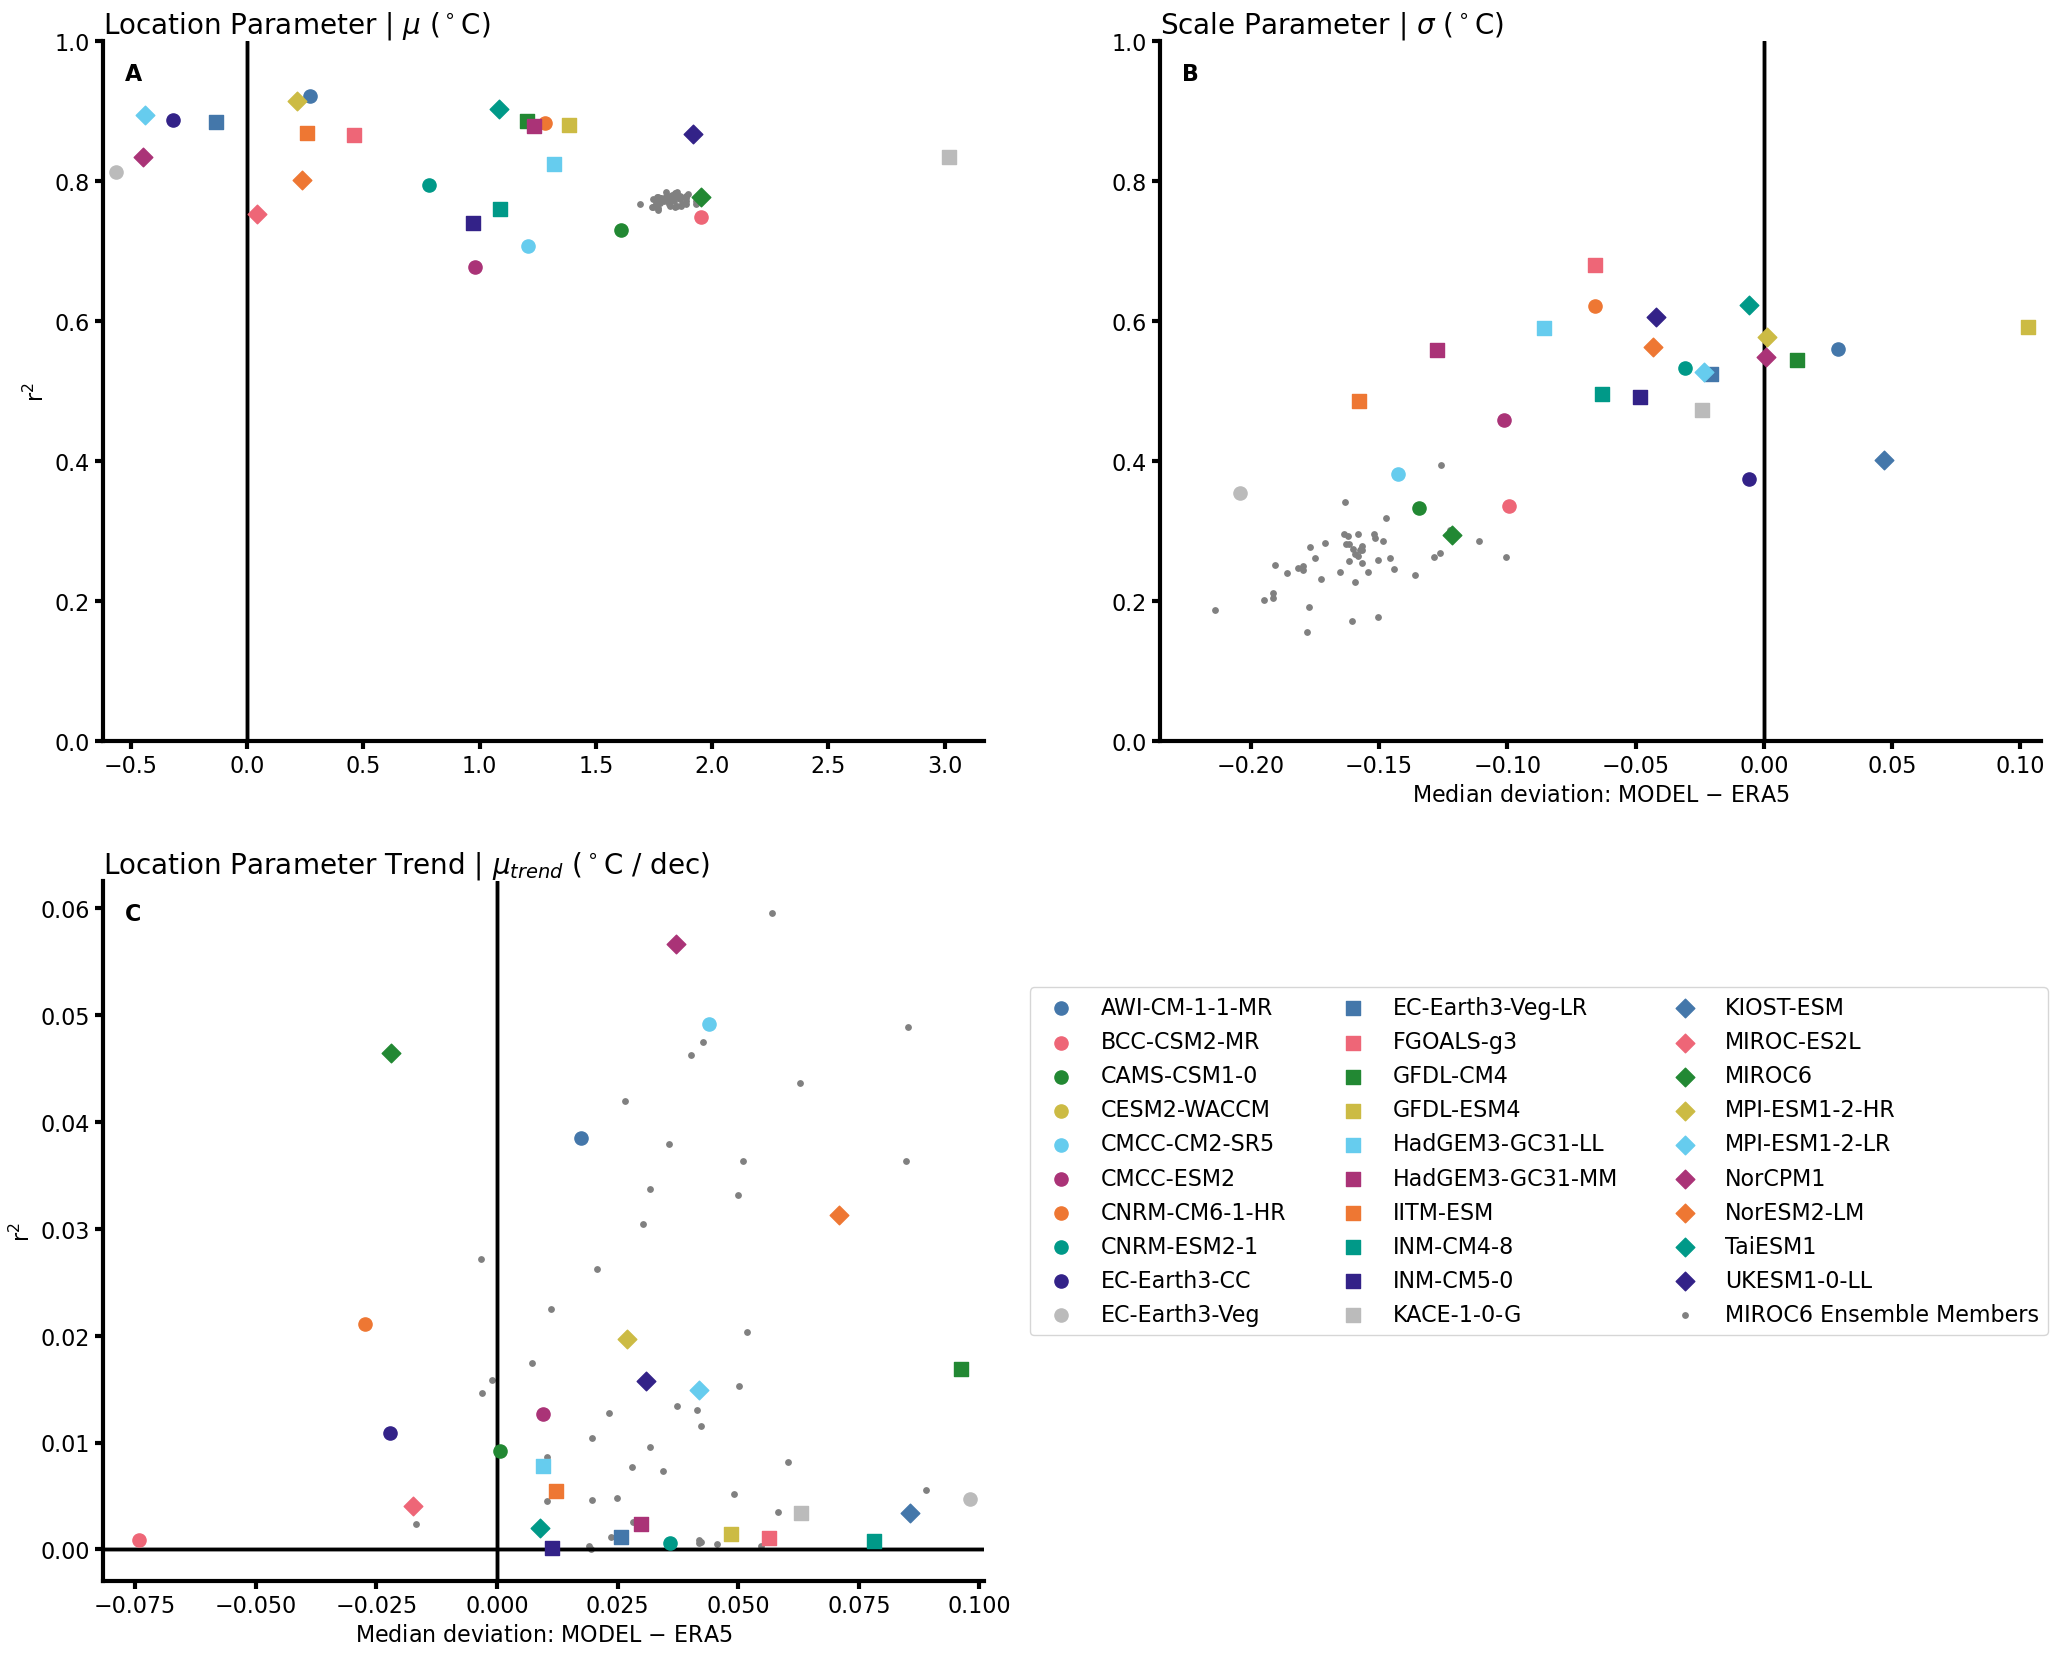

In [14]:
plot_bias_vs_corr(
    abs_dev_prim=med_abs_dev_prim, r2s_prim=r2s_prim,
    abs_dev_most=med_abs_dev_most, r2s_most=r2s_most,
    param_order=['loc', 'scale', 'loc_t'],
    models=list(CMIPConfig.iter_active_models(cmip_variable)),
    model_with_most=model_with_most, fit=fit, med_or_mean='med',
    fname=f'all_cmip_era5_r2_medbias_{cmip_variable}_{anom_type}_{fit}',
    save_figs=SAVE_FIGS
)

Figure saved to: /project/bbcael/ambauer/gev-heat-waves/analysis/figs/analysis/2026-05-15-all_cmip_era5_r2_meanbias_tas_annual_max_annmean_nonstat_gumbel_only_loc_trend.png


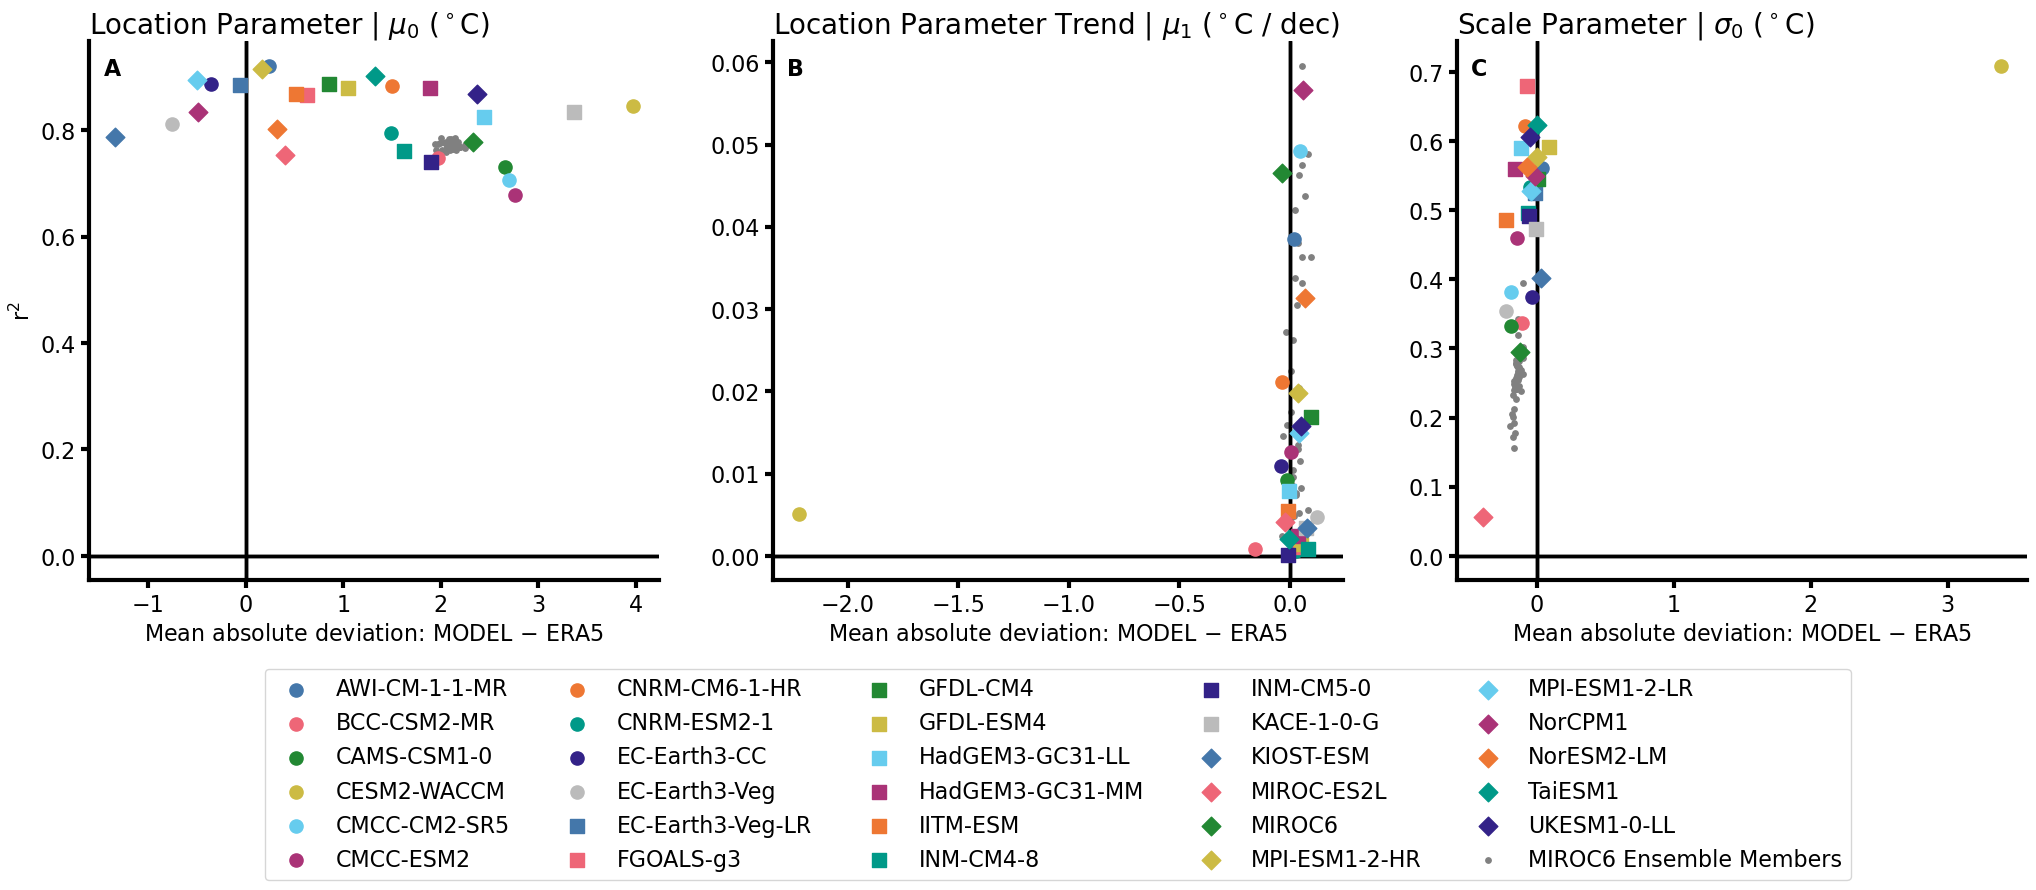

In [14]:
plot_bias_vs_corr(
    abs_dev_prim=mean_abs_dev_prim, r2s_prim=r2s_prim,
    abs_dev_most=mean_abs_dev_most, r2s_most=r2s_most,
    models=list(CMIPConfig.iter_active_models(cmip_variable)),
    model_with_most=model_with_most, fit=fit, med_or_mean='mean',
    fname=f'all_cmip_era5_r2_meanbias_{cmip_variable}_{anom_type}_{fit}',
    save_figs=SAVE_FIGS
)

## Additional analysis (quoted numbers, etc.)

In [36]:
merged_dict = {var: np.hstack([r2s_prim[var], r2s_most[var]]) for var in r2s_prim.keys()}

In [37]:
# make data frames of primary members only and primary + all the MIROC members 
models = list(CMIPConfig.iter_active_models(cmip_variable))
df_prim = pd.DataFrame(r2s_prim, index=[m.name for m in models])
df_merged = pd.DataFrame(merged_dict, index=[m.name for m in models] + [f'{model_with_most}_member_{i}' for i in range(N_members)])

# take means
prim_means = df_prim.mean()
merged_means = df_merged.mean()

prim_meds = df_prim.median()
merged_meds = df_merged.median()

prim_maxs = df_prim.max()
merged_maxs = df_merged.max()

In [44]:
print("SUMMARY STATISTICS")
print("-" * 80)
for p in MLE_FIT_ATTRS[fit]['param_names']:
    print(f"Parameter: {p}")
    print(f"    Primary members only - mean R^2: {prim_means[p]:.3f}, median R^2: {prim_meds[p]:.3f}, max R^2: {prim_maxs[p]:.3f}")
    print(f"    Primary + all members - mean R^2: {merged_means[p]:.3f}, median R^2: {merged_meds[p]:.3f}, max R^2: {merged_maxs[p]:.3f}\n")

SUMMARY STATISTICS
--------------------------------------------------------------------------------
Parameter: loc
    Primary members only - mean R^2: 0.847, median R^2: 0.860, max R^2: 0.921
    Primary + all members - mean R^2: 0.818, median R^2: 0.802, max R^2: 0.921

Parameter: scale
    Primary members only - mean R^2: 0.488, median R^2: 0.514, max R^2: 0.668
    Primary + all members - mean R^2: 0.345, median R^2: 0.288, max R^2: 0.668

Parameter: shape
    Primary members only - mean R^2: 0.003, median R^2: 0.001, max R^2: 0.013
    Primary + all members - mean R^2: 0.004, median R^2: 0.002, max R^2: 0.022

